In [14]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from scipy.stats import chi2_contingency

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import SGDClassifier, Perceptron, LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import sys
import json
from io import StringIO
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from lib.paths import M_KEN_TRAIN_ALL
with open(M_KEN_TRAIN_ALL, "r") as f:
        data = json.load(f)
df = pd.read_json(StringIO(data))
print(df.columns)

Index(['DataThrough', 'Season', 'TeamName', 'Seed', 'ConfShort', 'Coach',
       'Wins', 'Losses', 'AdjEM', 'RankAdjEM',
       ...
       'RankOppStlRate', 'OppNSTRate', 'RankOppNSTRate', 'OppARate',
       'RankOppARate', 'OppF3GRate', 'RankOppF3GRate', 'OppAvg2PADist',
       'RankOppAvg2PADist', 'Tourney'],
      dtype='object', length=129)


In [20]:
exceptions = ["Season", "Seed", "SEED"]
keep = []

if "TOURNEY" in df.columns:
    df = df.rename(columns={"TOURNEY": "Tourney"})

for col in df.columns:
    if col in exceptions:
        continue
    if df[col].dtype in [float, bool]:
        keep.append(col)

df = df[keep]

In [21]:
X = df.drop(columns=['Tourney'])
y = df['Tourney']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                    test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=10000, solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.91


In [22]:
# Coefficients and Odds Ratios
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)


# Display feature importance using coefficients and odds ratios
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by='Coefficient', ascending=False))


Feature Importance (Coefficient and Odds Ratio):
          Feature  Coefficient   Odds Ratio
8            Luck     7.108943  1222.854197
40     Continuity     0.642672     1.901555
10           SOSO     0.639307     1.895168
13        APL_Off     0.539381     1.714944
0           AdjEM     0.475712     1.609159
17        eFG_Pct     0.359136     1.432092
25          OffFt     0.341649     1.407266
6           Tempo     0.340883     1.406188
46        NSTRate     0.275006     1.316538
5              DE     0.267339     1.306483
16    ConfAPL_Def     0.227475     1.255426
51      OppFG2Pct     0.191661     1.211260
27         OffFg3     0.179778     1.196951
50      OppFG3Pct     0.171978     1.187652
30         DefFg3     0.155774     1.168562
28          DefFt     0.153625     1.166054
49     Avg2PADist     0.153115     1.165459
23        DOR_Pct     0.129189     1.137906
2           AdjOE     0.123840     1.131834
29         DefFg2     0.118259     1.125535
36           Hgt2     0.11

In [23]:
# Permutation Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
})
print("\nPermutation Importance:")
print(perm_importance_df.sort_values(by='Importance Mean', ascending=False))


Permutation Importance:
          Feature  Importance Mean  Importance Std
0           AdjEM         0.348653        0.008042
9             SOS         0.180393        0.005979
11           SOSD         0.142399        0.006329
10           SOSO         0.129007        0.007369
4           AdjDE         0.119489        0.007288
5              DE         0.049046        0.005329
6           Tempo         0.042399        0.005152
17        eFG_Pct         0.039921        0.004801
27         OffFg3         0.032940        0.004908
3              OE         0.032783        0.004398
48        F3GRate         0.029735        0.004850
2           AdjOE         0.029302        0.004703
25          OffFt         0.022950        0.005171
30         DefFg3         0.019213        0.003568
13        APL_Off         0.019174        0.003529
51      OppFG2Pct         0.017207        0.003527
1          Pythag         0.016146        0.002908
41         FG3Pct         0.014946        0.003501
21    

In [34]:
# Recursive Feature Elimination (RFE)
rfe_model = LogisticRegression()
rfe = RFE(rfe_model, n_features_to_select=10)
rfe.fit(X_train, y_train)


rfe_features = X.columns[rfe.support_]
print("\nSelected Features by RFE:")
print(rfe_features)


Selected Features by RFE:
Index(['G', 'ADJDE', 'EFG_O', 'TOR', 'TORD', 'ORB', 'FTR', '2P_O', '3P_O',
       '3P_D'],
      dtype='object')


In [35]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy # Requires: pip install boruta

# 1. SETUP - Aiming for top 10 features across all methods
n_select = 10
votes = pd.DataFrame({'Feature': X.columns})

# 2. FILTER METHODS (Statistical)
# ANOVA F-Value
skb = SelectKBest(f_classif, k=n_select).fit(X, y)
votes['SelectKBest'] = skb.get_support()

# Mutual Information (Captures non-linear dependencies)
mi = SelectKBest(mutual_info_classif, k=n_select).fit(X, y)
votes['Mutual_Info'] = mi.get_support()

# 3. WRAPPER METHODS (Iterative)
# RFE with Logistic Regression
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=n_select).fit(X, y)
votes['RFE'] = rfe.support_

# Boruta (Proves features are better than random shadow noise)
rf_boruta = RandomForestClassifier(n_jobs=-1, max_depth=5)
boruta = BorutaPy(rf_boruta, n_estimators='auto', verbose=0).fit(X.values, y.values)
votes['Boruta'] = boruta.support_

# 4. EMBEDDED METHODS (Model-Specific)
# Lasso (L1 Regularization - forces weak coefficients to zero)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.2).fit(X, y)
lasso_top = np.argsort(abs(lasso.coef_[0]))[-n_select:]
votes['Lasso_L1'] = [i in lasso_top for i in range(len(X.columns))]

# Random Forest Importance (Tree-based impurity reduction)
rf = RandomForestClassifier(n_estimators=100).fit(X, y)
rf_top = np.argsort(rf.feature_importances_)[-n_select:]
votes['RandomForest'] = [i in rf_top for i in range(len(X.columns))]

# 5. FINAL TALLY
votes['Total_Votes'] = votes.iloc[:, 1:].sum(axis=1)
# Filter for features selected by at least 3 methods
consensus_features = votes[votes['Total_Votes'] >= 3].sort_values(by='Total_Votes', ascending=False)

print(consensus_features)

    Feature  SelectKBest  Mutual_Info    RFE  Boruta  Lasso_L1  RandomForest  \
1     ADJOE         True         True   True    True      True          True   
2     ADJDE         True         True   True    True      True          True   
3   BARTHAG         True         True   True    True      True          True   
4     EFG_O         True         True   True    True      True          True   
5     EFG_D         True         True   True    True      True          True   
6       TOR         True         True   True    True      True          True   
13     2P_D         True         True   True    True     False          True   
0         G         True         True  False    True     False          True   
12     2P_O         True         True  False    True     False          True   
14     3P_O        False         True  False    True      True          True   
15     3P_D         True        False   True    True      True         False   
7      TORD        False        False   

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Isolate the Consensus Features
# Assuming 'consensus_features' is the list of names from the previous step
X_final = X[consensus_features['Feature']]

# 2. Re-split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Fit the Final Model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_scaled, y_train)

# 4. Generate Predictions
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1] # Probability of being a '1' (In Tourney)

# 5. Print Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.92      0.96      0.94       786
        True       0.79      0.64      0.71       186

    accuracy                           0.90       972
   macro avg       0.85      0.80      0.82       972
weighted avg       0.89      0.90      0.89       972

ROC-AUC Score: 0.9313


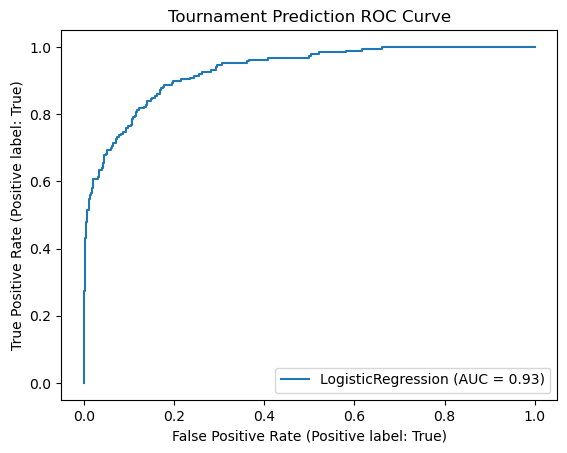

In [37]:
RocCurveDisplay.from_estimator(final_model, X_test_scaled, y_test)
plt.title("Tournament Prediction ROC Curve")
plt.show()

In [38]:
import time
def get_classifier_best(Classifier, X, y, tune=None, **params):
    print('Training classifier \'{}\'...'.format(Classifier.__name__))
    start_time = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=13, shuffle=True)
    clf = Classifier(**params)
    best_score = 0

    if tune:
        search = GridSearchCV(clf, tune, refit=True, n_jobs=-1)
        search.fit(X_train, y_train)

        best_params = search.best_params_
        best_score = search.best_score_
        print('{} scores: {}\twith {}'.format(Classifier.__name__, best_score, best_params))
        clf = search.best_estimator_
    else:
        cv_results = cross_validate(clf, X, y, cv=5)
        scores = cv_results['test_score']
        best_score = np.mean(scores)
        print('{} scores: {} ± {}'.format(Classifier.__name__, best_score, np.std(scores)))

        clf.fit(X_train, y_train)
    if hasattr(clf, 'feature_importances_') and hasattr(clf, 'feature_names_in_'):
        importances = sorted(zip(clf.feature_names_in_, clf.feature_importances_), key=lambda x: x[1], reverse=True)
        print('Feature Importances: {}'.format(importances))
    duration = time.time() - start_time
    print(f"⏱️ {Classifier.__name__} took {duration:.2f} seconds")
    return clf, best_score

In [39]:

# run ML models
models = []

tune_params = [{'strategy': ['uniform'], 'random_state': [13]}]
result = get_classifier_best(DummyClassifier, X, y, tune=None, strategy='uniform')
models.append(result)

tune_params = [{'fit_intercept': [True, False], 'positive': [True, False]}]
result = get_classifier_best(LinearRegression, X, y, tune=tune_params)
models.append(result)

print()
tune_params = [{'learning_rate': [0.01,0.05,0.1,0.15], 'n_estimators': [50,100,200]}]
result = get_classifier_best(GradientBoostingClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'C': [0.01, 0.1, 1.0, 2.0, 10.0, 20.0], 'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}
result = get_classifier_best(SVC, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'loss': ['hinge','log_loss','modified_huber','squared_hinge'], 'alpha': [0.0001, 0.001], 
    'learning_rate': ['optimal'], 'max_iter': [100000]}
result = get_classifier_best(SGDClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(GaussianNB, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(Perceptron, X, y, tune=tune_params)
models.append(result)

#print()
#tune_params = {'solver': ['lbfgs', 'adam'], 'batch_size': [16,32], 'hidden_layer_sizes': [(128), (128,64), (128,128,64), (512, 512, 128, 64)], 'max_iter': [10000]}
# result = get_classifier_best(MLPClassifier, X, y, tune=tune_params)
#models.append(result)

print()
tune_params = {'n_estimators': [20,50,100,200], 'learning_rate': [0.01,0.1,0.5]}
result = get_classifier_best(AdaBoostClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'n_neighbors': [3, 15, 25, 31], 'weights': ['uniform', 'distance'], 'p': [1, 2, 3]}
result = get_classifier_best(KNeighborsClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'criterion': ['entropy', 'gini'], 'splitter': ['best', 'random']}
result = get_classifier_best(DecisionTreeClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'n_estimators': [50, 100, 200], 'criterion': ['entropy', 'gini']}
result = get_classifier_best(RandomForestClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'max_iter_predict': [10, 100, 200]}
result = get_classifier_best(GaussianProcessClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [10000]
}

result = get_classifier_best(LogisticRegression, X, y, tune=tune_params)
models.append(result)

best_model, best_score = max(models, key=lambda x: x[1])
print('\nSelecting \'{}\' as best model with score: {}'.format(best_model.__class__.__name__, best_score))

Training classifier 'DummyClassifier'...


DummyClassifier scores: 0.5091377091377092 ± 0.012467316384362761
⏱️ DummyClassifier took 0.02 seconds
Training classifier 'LinearRegression'...
LinearRegression scores: 0.3722484648200938	with {'fit_intercept': False, 'positive': False}
⏱️ LinearRegression took 0.15 seconds

Training classifier 'GradientBoostingClassifier'...
GradientBoostingClassifier scores: 0.89873329678815	with {'learning_rate': 0.1, 'n_estimators': 200}
Feature Importances: [('BARTHAG', 0.652706154911356), ('G', 0.06051954589812586), ('EFG_D', 0.03233751296105165), ('TOR', 0.028321190800811063), ('EFG_O', 0.02824116340039155), ('FTR', 0.025641975668036297), ('3P_O', 0.023995486317780153), ('2P_O', 0.022998543328630442), ('ADJDE', 0.019576432767842336), ('ADJ_T', 0.016828090618030027), ('DRB', 0.015663327257596733), ('TORD', 0.014625427493409837), ('FTRD', 0.014494187680842414), ('3P_D', 0.013230099605309933), ('ADJOE', 0.011164991368985971), ('ORB', 0.01104747576353099), ('2P_D', 0.008608394158268863)]
⏱️ Gradie

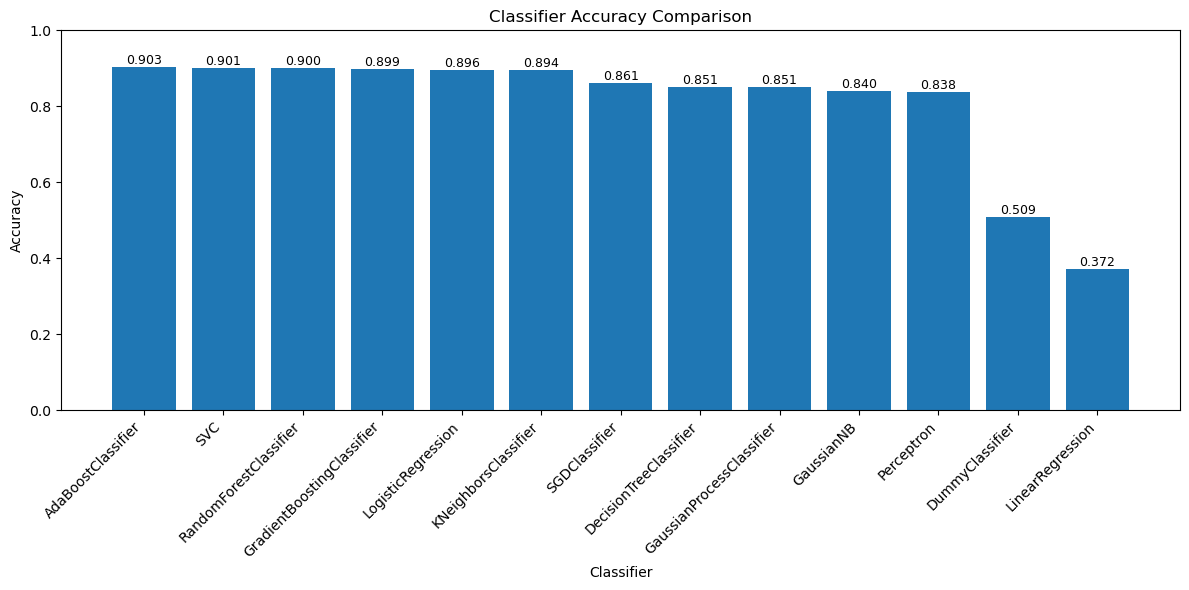

In [40]:
import matplotlib.pyplot as plt

models_sorted = sorted(models, key=lambda x: x[1], reverse=True)

model_names = [m.__class__.__name__ for m, s in models_sorted]
scores = [s for m, s in models_sorted]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, scores)

# Optional: show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.title("Classifier Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)  # assuming accuracy
plt.tight_layout()
plt.show()


SVC, GradientBoostingClassifier, Logistic Regression
https://chatgpt.com/share/697c3918-7494-8005-a060-587f1a0b7775